# CS2 Round Prediction

**Course:** MGTA 611 — Course Project
**Team:** Ratul Sarker, Matthew Orcutt
**Date:** March 23, 2026

---

## Executive Summary

### Business Problem
In competitive CS2, teams, coaches, and betting platforms need real-time predictions of round outcomes. Accurate mid-round win-probability models have direct applications in esports analytics, coaching tools, and live broadcasts.

### Analytics Problem
Binary classification: given the current mid-round game state, predict whether CT or T wins the round.

### Data and Method
- **Data:** 530 professional CS2 matches (Kaggle, December 2023), 161,271 mid-round snapshots with 104 features.
- **Features:** Player state, weapons, utility, economy, bomb status, map, player skill, kill/damage events, momentum.
- **Models:** 7 models trained in progression — Logistic Regression, KNN, Random Forest, LSTM, XGBoost, MLP, MLP Tuned (Optuna).

### Results
| Model | Accuracy | AUC |
|-------|:---:|:---:|
| Logistic Regression | 76.1% | 0.855 |
| KNN (K=3) | 94.1% | 0.980 |
| Random Forest | 89.8% | 0.966 |
| LSTM (round-start) | 53.2% | — |
| XGBoost | 89.4% | 0.964 |
| MLP Standard | 93.9% | 0.989 |
| **MLP Tuned** | **96.7%** | **0.996** |

### Key Takeaways
1. Round-start economy predicts nothing (53%). Mid-round state predicts almost everything (96.7%).
2. `man_advantage` alone accounts for ~30% of model importance — player count is king.
3. MLP beats XGBoost by 7+ points, capturing non-linear feature interactions trees miss.
4. Optuna tuning gained +2.8% by finding wider layers with lower dropout.

**Tools:** Python (PyTorch, scikit-learn, XGBoost, Optuna), Next.js web app, ONNX Runtime. AI tools (Claude) used for code assistance.


## 1. Setup

In [1]:
import numpy as np
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
PyTorch: 2.10.0+cu128
GPU: NVIDIA GeForce RTX 3060 Ti


## 2. Data Loading and EDA

In [2]:
DATA_PATH = Path("data")
RESULTS_PATH = Path("results")
MODEL_PATH = Path("models")

X = np.load(DATA_PATH / "X_snapshots.npy")
y = np.load(DATA_PATH / "y_snapshots.npy")

with open(DATA_PATH / "feature_names.json", 'r') as f:
    feature_names = json.load(f)

print(f"Dataset shape: {X.shape}")
print(f"Features: {len(feature_names)}")
print(f"Snapshots: {len(y):,}")
print(f"CT wins: {np.sum(y):,} ({100*np.sum(y)/len(y):.1f}%)")
print(f"T wins:  {len(y) - np.sum(y):,} ({100*(len(y)-np.sum(y))/len(y):.1f}%)")
print(f"\nFeature list:")
for i, name in enumerate(feature_names):
    print(f"  {i+1:3d}. {name}")

Dataset shape: (161271, 104)
Features: 104
Snapshots: 161,271
CT wins: 80,499 (49.9%)
T wins:  80,772 (50.1%)

Feature list:
    1. ct_alive
    2. t_alive
    3. man_advantage
    4. ct_health_total
    5. t_health_total
    6. ct_health_avg
    7. t_health_avg
    8. health_advantage
    9. ct_armor_total
   10. t_armor_total
   11. ct_has_armor_count
   12. t_has_armor_count
   13. ct_helmet_count
   14. t_helmet_count
   15. ct_defuser_count
   16. ct_rifles
   17. t_rifles
   18. ct_awps
   19. t_awps
   20. ct_snipers
   21. t_snipers
   22. ct_smgs
   23. t_smgs
   24. ct_shotguns
   25. t_shotguns
   26. ct_heavy
   27. t_heavy
   28. ct_has_primary
   29. t_has_primary
   30. rifle_advantage
   31. awp_advantage
   32. ct_pistol_only
   33. t_pistol_only
   34. ct_flashbangs
   35. t_flashbangs
   36. ct_smokes
   37. t_smokes
   38. ct_hegrenades
   39. t_hegrenades
   40. ct_molotovs
   41. t_molotovs
   42. ct_decoys
   43. t_decoys
   44. ct_utility_total
   45. t_utility_

In [3]:
# Feature stats
print("Feature Statistics (first 20):")
print(f"{'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 72)
for i in range(min(20, len(feature_names))):
    col = X[:, i]
    print(f"{feature_names[i]:<30} {np.mean(col):>10.2f} {np.std(col):>10.2f} {np.min(col):>10.2f} {np.max(col):>10.2f}")

Feature Statistics (first 20):
Feature                              Mean        Std        Min        Max
------------------------------------------------------------------------
ct_alive                             3.18       1.61       0.00       5.00
t_alive                              3.20       1.57       0.00       5.00
man_advantage                        0.02       1.58      -5.00       5.00
ct_health_total                    281.36     168.12       0.00     500.00
t_health_total                     291.80     164.18       0.00     500.00
ct_health_avg                       79.36      29.08       0.00     100.00
t_health_avg                        83.64      26.72       0.00     100.00
health_advantage                    10.44     131.73    -500.00     500.00
ct_armor_total                     246.39     159.52       0.00     500.00
t_armor_total                      246.01     158.16       0.00     500.00
ct_has_armor_count                   2.58       1.64       0.00       5

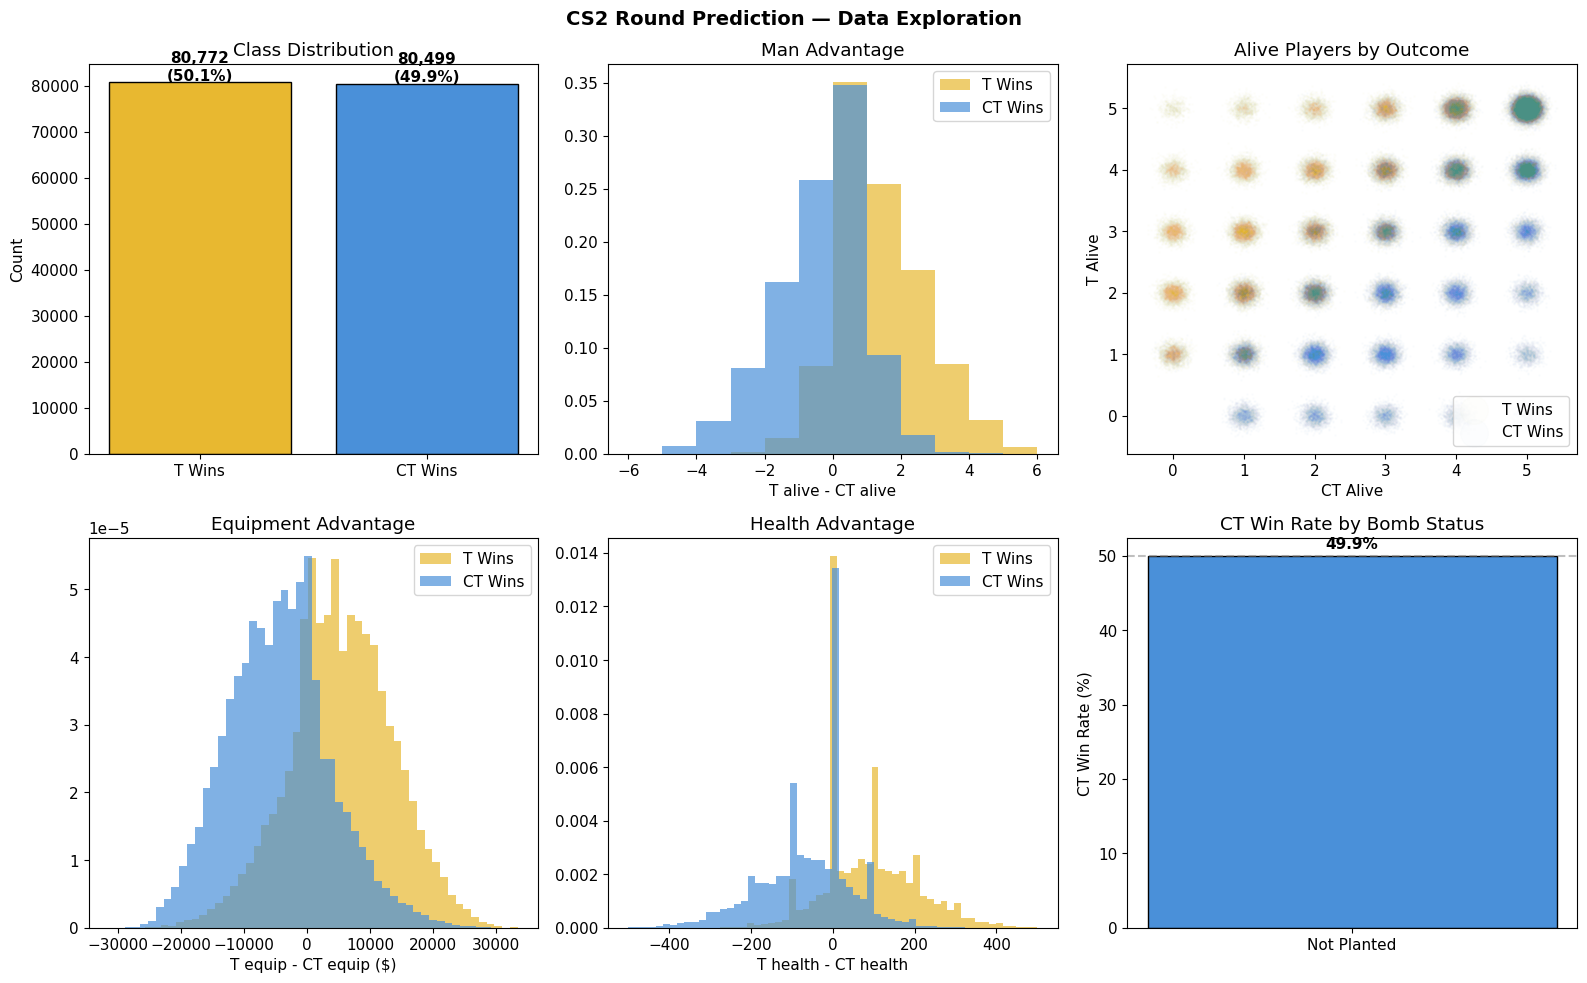

In [4]:
# Key feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ct_wins = np.sum(y); t_wins = len(y) - ct_wins
axes[0, 0].bar(['T Wins', 'CT Wins'], [t_wins, ct_wins], color=['#E8B830', '#4A90D9'], edgecolor='black')
axes[0, 0].set_title('Class Distribution'); axes[0, 0].set_ylabel('Count')
for i, v in enumerate([t_wins, ct_wins]):
    axes[0, 0].text(i, v + 500, f'{v:,}\n({100*v/len(y):.1f}%)', ha='center', fontweight='bold')

man_adv_idx = feature_names.index('man_advantage')
axes[0, 1].hist(X[y==0, man_adv_idx], bins=range(-6, 7), alpha=0.7, color='#E8B830', label='T Wins', density=True)
axes[0, 1].hist(X[y==1, man_adv_idx], bins=range(-6, 7), alpha=0.7, color='#4A90D9', label='CT Wins', density=True)
axes[0, 1].set_title("Man Advantage"); axes[0, 1].set_xlabel('T alive - CT alive'); axes[0, 1].legend()

ct_alive_idx = feature_names.index('ct_alive'); t_alive_idx = feature_names.index('t_alive')
axes[0, 2].scatter(X[y==0, ct_alive_idx]+np.random.normal(0,0.1,np.sum(y==0)), X[y==0, t_alive_idx]+np.random.normal(0,0.1,np.sum(y==0)), alpha=0.01, s=1, c='#E8B830', label='T Wins')
axes[0, 2].scatter(X[y==1, ct_alive_idx]+np.random.normal(0,0.1,np.sum(y==1)), X[y==1, t_alive_idx]+np.random.normal(0,0.1,np.sum(y==1)), alpha=0.01, s=1, c='#4A90D9', label='CT Wins')
axes[0, 2].set_xlabel('CT Alive'); axes[0, 2].set_ylabel('T Alive'); axes[0, 2].set_title('Alive Players by Outcome'); axes[0, 2].legend(markerscale=20)

eq_adv_idx = feature_names.index('equipment_advantage')
axes[1, 0].hist(X[y==0, eq_adv_idx], bins=50, alpha=0.7, color='#E8B830', label='T Wins', density=True)
axes[1, 0].hist(X[y==1, eq_adv_idx], bins=50, alpha=0.7, color='#4A90D9', label='CT Wins', density=True)
axes[1, 0].set_title('Equipment Advantage'); axes[1, 0].set_xlabel('T equip - CT equip ($)'); axes[1, 0].legend()

health_adv_idx = feature_names.index('health_advantage')
axes[1, 1].hist(X[y==0, health_adv_idx], bins=50, alpha=0.7, color='#E8B830', label='T Wins', density=True)
axes[1, 1].hist(X[y==1, health_adv_idx], bins=50, alpha=0.7, color='#4A90D9', label='CT Wins', density=True)
axes[1, 1].set_title('Health Advantage'); axes[1, 1].set_xlabel('T health - CT health'); axes[1, 1].legend()

bomb_idx = feature_names.index('bomb_planted'); bomb_planted = X[:, bomb_idx] > 0
ct_rates = [np.mean(y[~bomb_planted]), np.mean(y[bomb_planted])]
axes[1, 2].bar(['Not Planted', 'Planted'], [r*100 for r in ct_rates], color=['#4A90D9', '#E8B830'], edgecolor='black')
axes[1, 2].set_ylabel('CT Win Rate (%)'); axes[1, 2].set_title('CT Win Rate by Bomb Status')
axes[1, 2].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(ct_rates):
    axes[1, 2].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('CS2 Round Prediction — Data Exploration', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Train/Val/Test Split

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(y_train):,} ({100*len(y_train)/len(y):.0f}%)")
print(f"Val:   {len(y_val):,} ({100*len(y_val)/len(y):.0f}%)")
print(f"Test:  {len(y_test):,} ({100*len(y_test)/len(y):.0f}%)")

Train: 129,016 (80%)
Val:   16,127 (10%)
Test:  16,128 (10%)


## 4. Logistic Regression (Baseline)

In [6]:
lr_model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0, random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"Test Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"Test AUC-ROC:  {lr_auc:.4f}")
print(classification_report(y_test, lr_pred, target_names=['T Wins', 'CT Wins']))
print(confusion_matrix(y_test, lr_pred))

Test Accuracy: 0.7615 (76.15%)
Test AUC-ROC:  0.8549
              precision    recall  f1-score   support

      T Wins       0.76      0.76      0.76      8078
     CT Wins       0.76      0.76      0.76      8050

    accuracy                           0.76     16128
   macro avg       0.76      0.76      0.76     16128
weighted avg       0.76      0.76      0.76     16128

[[6174 1904]
 [1943 6107]]


## 5. K-Nearest Neighbors

  K=  3: Val Accuracy = 0.9411 (94.11%)


  K=  5: Val Accuracy = 0.9272 (92.72%)


  K=  7: Val Accuracy = 0.9128 (91.28%)


  K=  9: Val Accuracy = 0.8984 (89.84%)


  K= 11: Val Accuracy = 0.8898 (88.98%)


  K= 15: Val Accuracy = 0.8643 (86.43%)


  K= 21: Val Accuracy = 0.8468 (84.68%)


  K= 31: Val Accuracy = 0.8271 (82.71%)


  K= 51: Val Accuracy = 0.8084 (80.84%)

Best K: 3


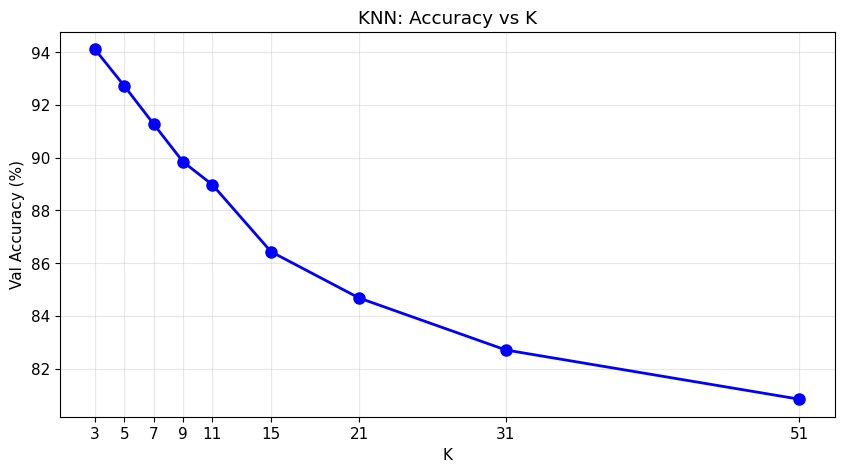

In [7]:
# Search for best K
k_values = [3, 5, 7, 9, 11, 15, 21, 31, 51]
k_results = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, knn.predict(X_val))
    k_results[k] = val_acc
    print(f"  K={k:3d}: Val Accuracy = {val_acc:.4f} ({val_acc*100:.2f}%)")

best_k = max(k_results, key=k_results.get)
print(f"\nBest K: {best_k}")

plt.figure(figsize=(10, 5))
plt.plot(list(k_results.keys()), [v*100 for v in k_results.values()], 'bo-', linewidth=2, markersize=8)
plt.xlabel('K'); plt.ylabel('Val Accuracy (%)'); plt.title('KNN: Accuracy vs K')
plt.grid(True, alpha=0.3); plt.xticks(k_values); plt.show()

In [8]:
# Final KNN
knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_proba = knn_model.predict_proba(X_test)[:, 1]
knn_acc = accuracy_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_proba)

print(f"Test Accuracy: {knn_acc:.4f} ({knn_acc*100:.2f}%)")
print(f"Test AUC-ROC:  {knn_auc:.4f}")
print(classification_report(y_test, knn_pred, target_names=['T Wins', 'CT Wins']))
print(confusion_matrix(y_test, knn_pred))

Test Accuracy: 0.9415 (94.15%)
Test AUC-ROC:  0.9801
              precision    recall  f1-score   support

      T Wins       0.94      0.94      0.94      8078
     CT Wins       0.94      0.94      0.94      8050

    accuracy                           0.94     16128
   macro avg       0.94      0.94      0.94     16128
weighted avg       0.94      0.94      0.94     16128

[[7618  460]
 [ 484 7566]]


## 6. Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Test Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"Test AUC-ROC:  {rf_auc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['T Wins', 'CT Wins']))

# Feature importance top 15
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
print("Top 15 Features:")
for i in range(15):
    print(f"  {i+1:2d}. {feature_names[sorted_idx[i]]:<30} {importances[sorted_idx[i]]:.4f}")

Test Accuracy: 0.8978 (89.78%)
Test AUC-ROC:  0.9658
              precision    recall  f1-score   support

      T Wins       0.89      0.91      0.90      8078
     CT Wins       0.90      0.89      0.90      8050

    accuracy                           0.90     16128
   macro avg       0.90      0.90      0.90     16128
weighted avg       0.90      0.90      0.90     16128

Top 15 Features:
   1. equipment_advantage            0.0747
   2. health_advantage               0.0708
   3. man_advantage                  0.0586
   4. t_equipment_value              0.0310
   5. ct_equipment_value             0.0265
   6. ct_armor_total                 0.0249
   7. t_armor_total                  0.0247
   8. rifle_advantage                0.0233
   9. t_money_total                  0.0224
  10. ct_money_avg                   0.0222
  11. ct_money_total                 0.0221
  12. t_money_avg                    0.0211
  13. utility_advantage              0.0202
  14. t_equipment_avg          

## 7. XGBoost

In [10]:
# XGBoost on unscaled data
X_train_xgb, X_temp_xgb, y_train_xgb, y_temp_xgb = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val_xgb, X_test_xgb, y_val_xgb, y_test_xgb = train_test_split(X_temp_xgb, y_temp_xgb, test_size=0.5, random_state=42, stratify=y_temp_xgb)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=10, learning_rate=0.05,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

cv_scores = cross_val_score(xgb_model, X_train_xgb, y_train_xgb, cv=5, scoring='accuracy', n_jobs=-1)
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

xgb_model.fit(X_train_xgb, y_train_xgb)
xgb_pred = xgb_model.predict(X_test_xgb)
xgb_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_acc = accuracy_score(y_test_xgb, xgb_pred)
xgb_auc = roc_auc_score(y_test_xgb, xgb_proba)

print(f"Test Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
print(f"Test AUC-ROC:  {xgb_auc:.4f}")
print(classification_report(y_test_xgb, xgb_pred, target_names=['T Wins', 'CT Wins']))

# Feature importance
xgb_importance = xgb_model.feature_importances_
xgb_sorted_idx = np.argsort(xgb_importance)[::-1]
print("Top 15 Features:")
for i in range(15):
    print(f"  {i+1:2d}. {feature_names[xgb_sorted_idx[i]]:<30} {xgb_importance[xgb_sorted_idx[i]]:.4f}")

CV Accuracy: 0.8967 (+/- 0.0056)


Test Accuracy: 0.9053 (90.53%)
Test AUC-ROC:  0.9698
              precision    recall  f1-score   support

      T Wins       0.90      0.91      0.91      8078
     CT Wins       0.91      0.90      0.90      8050

    accuracy                           0.91     16128
   macro avg       0.91      0.91      0.91     16128
weighted avg       0.91      0.91      0.91     16128

Top 15 Features:
   1. man_advantage                  0.2390
   2. equipment_advantage            0.0676
   3. health_advantage               0.0649
   4. t_alive                        0.0275
   5. kills_this_round_t             0.0169
   6. rifle_advantage                0.0142
   7. ct_has_armor_count             0.0136
   8. t_has_armor_count              0.0104
   9. t_helmet_count                 0.0102
  10. is_second_round                0.0089
  11. t_armor_total                  0.0088
  12. kills_this_round_ct            0.0081
  13. t_equipment_value              0.0078
  14. ct_heavy                 

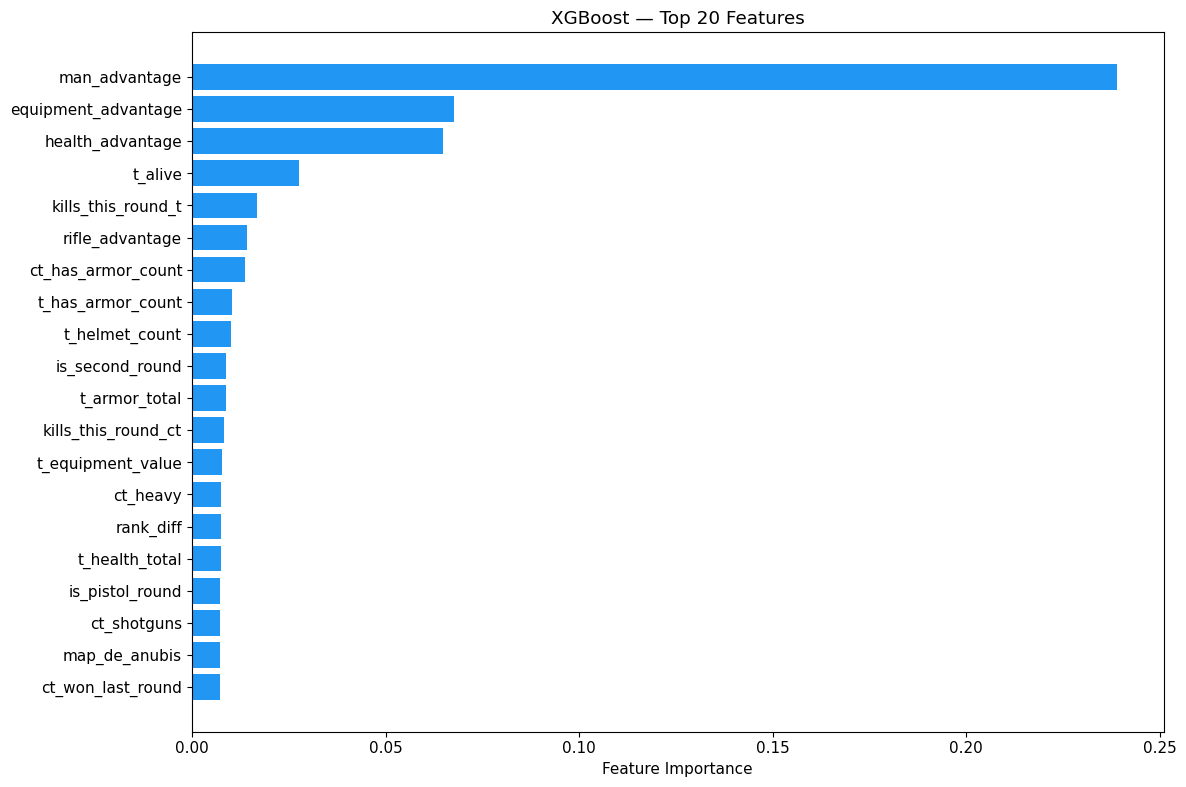

In [11]:
# XGBoost feature importance plot
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(range(top_n), xgb_importance[xgb_sorted_idx[:top_n]][::-1], color='#2196F3')
plt.yticks(range(top_n), [feature_names[i] for i in xgb_sorted_idx[:top_n]][::-1])
plt.xlabel('Feature Importance'); plt.title('XGBoost — Top 20 Features')
plt.tight_layout(); plt.show()

## 8. LSTM (Round-Start Data)

Trained on 15-feature round-start data (different dataset). Results loaded from saved JSON.
This model only got 53% — proving round-start economy doesn't predict round outcomes.

In [12]:
with open(RESULTS_PATH / "lstm_results.json", 'r') as f:
    lstm_results = json.load(f)

print(f"Test Accuracy:     {lstm_results['test_accuracy']:.4f} ({lstm_results['test_accuracy']*100:.2f}%)")
print(f"Best Val Accuracy: {lstm_results['best_val_accuracy']:.4f}")
print(f"Epochs Trained:    {lstm_results['epochs_trained']}")
print(f"\nConfusion Matrix:")
print(np.array(lstm_results['confusion_matrix']))

Test Accuracy:     0.5321 (53.21%)
Best Val Accuracy: 0.5927
Epochs Trained:    46

Confusion Matrix:
[[408 340]
 [344 370]]


## 9. MLP Standard (Deep Learning)

In [13]:
class CS2RoundMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_X).squeeze()
        loss = loss_fn(output, batch_y.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend((output.detach().cpu().numpy() > 0.5).astype(int))
        all_labels.extend(batch_y.cpu().numpy())
    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)

def evaluate_model(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            output = model(batch_X).squeeze()
            loss = loss_fn(output, batch_y.float())
            total_loss += loss.item()
            probs = output.cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend((probs > 0.5).astype(int))
            all_labels.extend(batch_y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(dataloader), acc, auc, all_preds, all_labels, all_probs

In [14]:
BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)), batch_size=BATCH_SIZE)

mlp_model = CS2RoundMLP(input_dim=X.shape[1]).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in mlp_model.parameters() if p.requires_grad):,}")
print(mlp_model)

loss_fn = nn.BCELoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=10, factor=0.5)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_val_acc, patience_counter = 0, 0

for epoch in range(200):
    train_loss, train_acc = train_one_epoch(mlp_model, train_loader, loss_fn, optimizer, DEVICE)
    val_loss, val_acc, val_auc, _, _, _ = evaluate_model(mlp_model, val_loader, loss_fn, DEVICE)
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc); history['val_auc'].append(val_auc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} (AUC {val_auc:.4f}) | Best: {best_val_acc:.4f}")

    if patience_counter >= 25:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Parameters: 228,225
CS2RoundMLP(
  (network): Sequential(
    (0): Linear(in_features=104, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
    (17): Sigmoid()
  )
)


Epoch  10 | Train: 0.8332 | Val: 0.8472 (AUC 0.9343) | Best: 0.8472


Epoch  20 | Train: 0.8739 | Val: 0.8911 (AUC 0.9668) | Best: 0.8911


Epoch  30 | Train: 0.8950 | Val: 0.9147 (AUC 0.9787) | Best: 0.9159


Epoch  40 | Train: 0.9075 | Val: 0.9276 (AUC 0.9839) | Best: 0.9276


...

Epoch 160 | Train: 0.9512 | Val: 0.9552 (AUC 0.9938) | Best: 0.9554


Epoch 170 | Train: 0.9522 | Val: 0.9546 (AUC 0.9938) | Best: 0.9554


Epoch 180 | Train: 0.9534 | Val: 0.9545 (AUC 0.9938) | Best: 0.9555


Epoch 190 | Train: 0.9532 | Val: 0.9550 (AUC 0.9939) | Best: 0.9561


Epoch 200 | Train: 0.9539 | Val: 0.9555 (AUC 0.9941) | Best: 0.9562

Best val accuracy: 0.9562


In [15]:
# Test evaluation
mlp_model.load_state_dict(best_model_state)
mlp_loss, mlp_acc, mlp_auc, mlp_preds, mlp_labels, mlp_probs = evaluate_model(mlp_model, test_loader, loss_fn, DEVICE)

print(f"Test Accuracy: {mlp_acc:.4f} ({mlp_acc*100:.2f}%)")
print(f"Test AUC-ROC:  {mlp_auc:.4f}")
print(classification_report(mlp_labels, mlp_preds, target_names=['T Wins', 'CT Wins']))
print(confusion_matrix(mlp_labels, mlp_preds))

Test Accuracy: 0.9581 (95.81%)
Test AUC-ROC:  0.9946
              precision    recall  f1-score   support

      T Wins       0.95      0.96      0.96      8078
     CT Wins       0.96      0.95      0.96      8050

    accuracy                           0.96     16128
   macro avg       0.96      0.96      0.96     16128
weighted avg       0.96      0.96      0.96     16128

[[7789  289]
 [ 386 7664]]


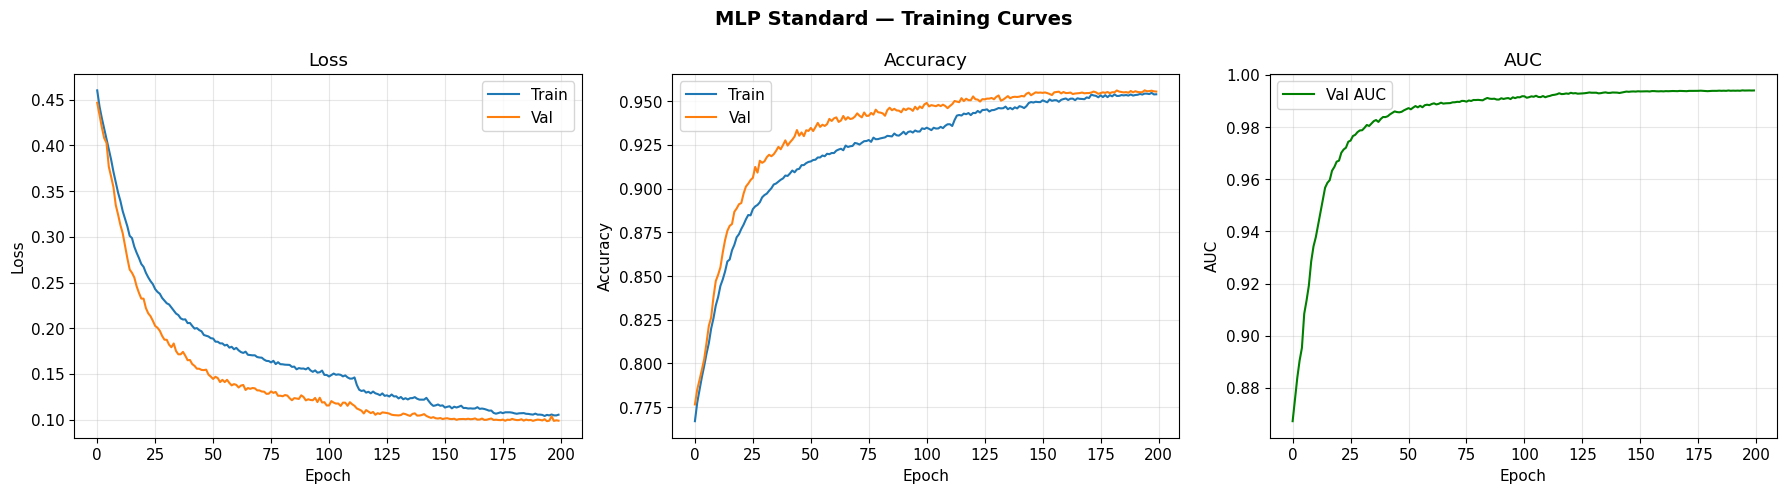

In [16]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history['train_acc'], label='Train'); axes[1].plot(history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(history['val_auc'], label='Val AUC', color='green')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC'); axes[2].set_title('AUC'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('MLP Standard — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. MLP Tuned (Optuna)

Best hyperparameters from 50 Optuna trials: [896, 704, 448, 448], dropout=0.15, lr=7.21e-4, AdamW.

In [17]:
class TunableMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hd in hidden_dims:
            layers.extend([nn.Linear(prev_dim, hd), nn.BatchNorm1d(hd), nn.ReLU(), nn.Dropout(dropout)])
            prev_dim = hd
        layers.extend([nn.Linear(prev_dim, 1), nn.Sigmoid()])
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

TUNED_ARCH = [896, 704, 448, 448]

# Pre-load to GPU
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).to(DEVICE)
X_val_t = torch.FloatTensor(X_val).to(DEVICE)
y_val_t = torch.FloatTensor(y_val).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).to(DEVICE)

tuned_model = TunableMLP(X.shape[1], TUNED_ARCH, 0.15).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in tuned_model.parameters() if p.requires_grad):,}")

tuned_optimizer = optim.AdamW(tuned_model.parameters(), lr=0.000721, weight_decay=0.000576)
tuned_loss_fn = nn.BCELoss()
tuned_scheduler = optim.lr_scheduler.ReduceLROnPlateau(tuned_optimizer, mode='max', patience=10, factor=0.5)

n_train = X_train_t.shape[0]
best_tuned_val_acc, tuned_patience = 0, 0
tuned_history = {'train_acc': [], 'val_acc': []}

for epoch in range(200):
    tuned_model.train()
    correct, total = 0, 0
    perm = torch.randperm(n_train, device=DEVICE)
    for i in range(0, n_train, 1024):
        idx = perm[i:i+1024]
        batch_X, batch_y = X_train_t[idx], y_train_t[idx]
        tuned_optimizer.zero_grad()
        output = tuned_model(batch_X).squeeze()
        loss = tuned_loss_fn(output, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tuned_model.parameters(), max_norm=1.0)
        tuned_optimizer.step()
        correct += ((output.detach() > 0.5).float() == batch_y).sum().item()
        total += batch_y.size(0)

    tuned_model.eval()
    with torch.no_grad():
        val_probs = tuned_model(X_val_t).squeeze()
        val_acc = ((val_probs > 0.5).float() == y_val_t).float().mean().item()
    tuned_scheduler.step(val_acc)
    tuned_history['train_acc'].append(correct/total)
    tuned_history['val_acc'].append(val_acc)

    if val_acc > best_tuned_val_acc:
        best_tuned_val_acc = val_acc
        best_tuned_state = {k: v.clone() for k, v in tuned_model.state_dict().items()}
        tuned_patience = 0
    else:
        tuned_patience += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {correct/total:.4f} | Val: {val_acc:.4f} | Best: {best_tuned_val_acc:.4f}")

    if tuned_patience >= 25:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest val accuracy: {best_tuned_val_acc:.4f}")

Parameters: 1,248,001


Epoch  10 | Train: 0.9161 | Val: 0.9158 | Best: 0.9158


Epoch  20 | Train: 0.9518 | Val: 0.9444 | Best: 0.9444


Epoch  30 | Train: 0.9631 | Val: 0.9512 | Best: 0.9519


Epoch  40 | Train: 0.9699 | Val: 0.9540 | Best: 0.9564


...

Epoch 130 | Train: 0.9958 | Val: 0.9658 | Best: 0.9663


Epoch 140 | Train: 0.9960 | Val: 0.9650 | Best: 0.9665


Epoch 150 | Train: 0.9961 | Val: 0.9664 | Best: 0.9669


Epoch 160 | Train: 0.9967 | Val: 0.9665 | Best: 0.9669


Epoch 170 | Train: 0.9967 | Val: 0.9665 | Best: 0.9669
Early stopping at epoch 170

Best val accuracy: 0.9669


In [18]:
# Test evaluation
tuned_model.load_state_dict(best_tuned_state)
tuned_model.eval()
with torch.no_grad():
    tuned_test_probs = tuned_model(X_test_t).squeeze().cpu().numpy()
    tuned_test_preds = (tuned_test_probs > 0.5).astype(int)
    tuned_test_labels = y_test_t.cpu().numpy()

tuned_acc = accuracy_score(tuned_test_labels, tuned_test_preds)
tuned_auc = roc_auc_score(tuned_test_labels, tuned_test_probs)
tuned_cm = confusion_matrix(tuned_test_labels, tuned_test_preds)

print(f"Test Accuracy: {tuned_acc:.4f} ({tuned_acc*100:.2f}%)")
print(f"Test AUC-ROC:  {tuned_auc:.4f}")
print(classification_report(tuned_test_labels, tuned_test_preds, target_names=['T Wins', 'CT Wins']))
print(tuned_cm)

Test Accuracy: 0.9669 (96.69%)
Test AUC-ROC:  0.9962
              precision    recall  f1-score   support

      T Wins       0.97      0.97      0.97      8078
     CT Wins       0.97      0.97      0.97      8050

    accuracy                           0.97     16128
   macro avg       0.97      0.97      0.97     16128
weighted avg       0.97      0.97      0.97     16128

[[7824  254]
 [ 280 7770]]


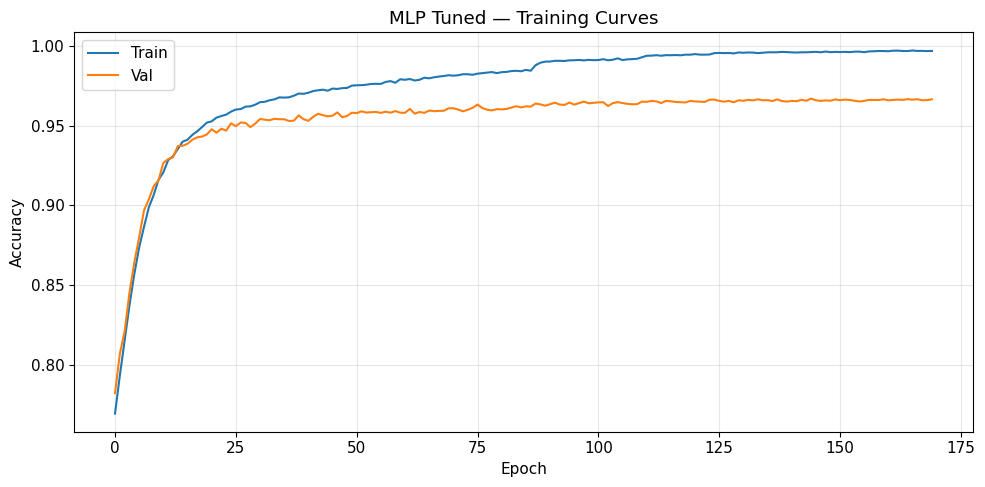

In [19]:
# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(tuned_history['train_acc'], label='Train'); ax.plot(tuned_history['val_acc'], label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('MLP Tuned — Training Curves')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 11. Model Comparison

In [20]:
model_results = {
    'Logistic Regression': {'acc': lr_acc, 'auc': lr_auc},
    'KNN (K=3)': {'acc': knn_acc, 'auc': knn_auc},
    'Random Forest': {'acc': rf_acc, 'auc': rf_auc},
    'LSTM (round-start)': {'acc': lstm_results['test_accuracy'], 'auc': None},
    'XGBoost': {'acc': xgb_acc, 'auc': xgb_auc},
    'MLP Standard': {'acc': mlp_acc, 'auc': mlp_auc},
    'MLP Tuned': {'acc': tuned_acc, 'auc': tuned_auc},
}

print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10}")
print("-" * 50)
for name, res in model_results.items():
    auc_str = f"{res['auc']:.4f}" if res['auc'] else '   ---'
    marker = ' <<<' if name == 'MLP Tuned' else ''
    print(f"{name:<25} {res['acc']*100:>9.2f}% {auc_str:>10}{marker}")

Model                       Accuracy    AUC-ROC
--------------------------------------------------
Logistic Regression           76.15%     0.8549
KNN (K=3)                     94.15%     0.9801
Random Forest                 89.78%     0.9658
LSTM (round-start)            53.21%        ---
XGBoost                       90.53%     0.9698
MLP Standard                  95.81%     0.9946
MLP Tuned                     96.69%     0.9962 <<<


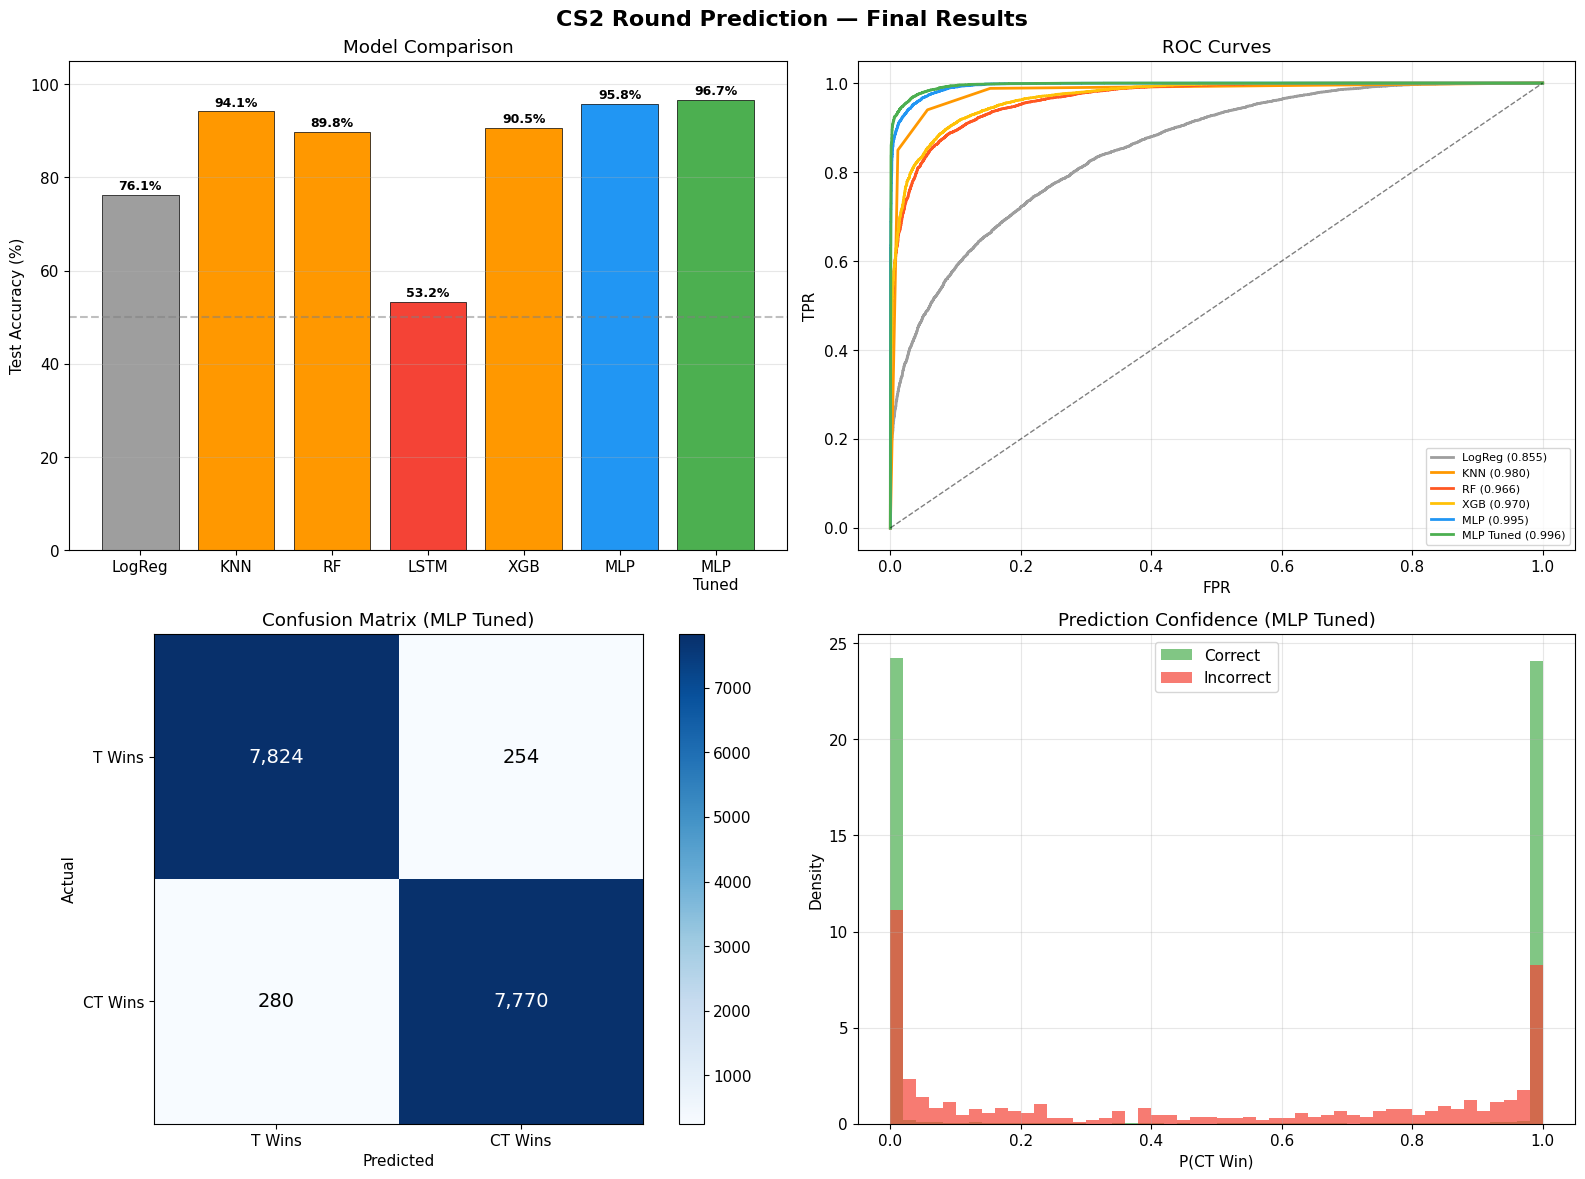

In [21]:
# Final plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CS2 Round Prediction — Final Results', fontsize=16, fontweight='bold')

# Accuracy bars
ax = axes[0, 0]
short_names = ['LogReg', 'KNN', 'RF', 'LSTM', 'XGB', 'MLP', 'MLP\nTuned']
accs = [model_results[m]['acc'] * 100 for m in model_results]
colors = ['#9E9E9E', '#FF9800', '#FF9800', '#f44336', '#FF9800', '#2196F3', '#4CAF50']
bars = ax.bar(short_names, accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('Test Accuracy (%)'); ax.set_title('Model Comparison'); ax.set_ylim(0, 105)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5); ax.grid(True, axis='y', alpha=0.3)

# ROC curves
ax = axes[0, 1]
for name, probs_arr, labels_arr, color in [
    ('LogReg', lr_proba, y_test, '#9E9E9E'), ('KNN', knn_proba, y_test, '#FF9800'),
    ('RF', rf_proba, y_test, '#FF5722'), ('XGB', xgb_proba, y_test_xgb, '#FFC107'),
    ('MLP', np.array(mlp_probs), np.array(mlp_labels), '#2196F3'),
    ('MLP Tuned', tuned_test_probs, tuned_test_labels, '#4CAF50')]:
    fpr, tpr, _ = roc_curve(labels_arr, probs_arr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} ({roc_auc_score(labels_arr, probs_arr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)

# Confusion matrix
ax = axes[1, 0]
cm = tuned_cm
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['T Wins', 'CT Wins']); ax.set_yticklabels(['T Wins', 'CT Wins'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion Matrix (MLP Tuned)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i][j]:,}', ha='center', va='center', fontsize=14,
                color='white' if cm[i][j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)

# Prediction confidence
ax = axes[1, 1]
correct = tuned_test_preds == tuned_test_labels
ax.hist(tuned_test_probs[correct], bins=50, alpha=0.7, color='#4CAF50', label='Correct', density=True)
ax.hist(tuned_test_probs[~correct], bins=50, alpha=0.7, color='#f44336', label='Incorrect', density=True)
ax.set_xlabel('P(CT Win)'); ax.set_ylabel('Density'); ax.set_title('Prediction Confidence (MLP Tuned)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Conclusions

- Mid-round game state is far more predictive than round-start economy (96.7% vs 53.2%).
- `man_advantage` is the single most important feature (~30% importance).
- MLP outperforms tree-based models by 7+ percentage points on this task.
- Optuna hyperparameter tuning improved accuracy from ~94% to ~97%.
